In [1]:
# Cell 1: Imports and Load Data
from utils import load_datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

datasets = load_datasets()


In [2]:
# Cell 2: EDA + Visuals Function
def explore_dataset(df, dataset_name):
    print(f"\n=== EDA for {dataset_name} ===")
    print(f"Shape: {df.shape}")

    # Missing Values
    print("\n🔹 Missing Values (%):")
    missing = df.isnull().mean() * 100
    print(missing[missing > 0].sort_values(ascending=False))

    # Value Counts
    print("\n🔹 Value Counts (Top Categorical Columns):")
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].nunique() < 20:
            print(f"\n▶ {col}:\n{df[col].value_counts(dropna=False)}")

    # Descriptive Stats
    print("\n🔹 Descriptive Stats (Numeric Columns):")
    print(df.describe())

    # Plots
    print("\n📊 Plotting...")

    # === Dataset-specific plots ===
    if dataset_name == 'dataset_1':
        symptom_cols = ['Fever', 'Dry-Cough', 'Difficulty-in-Breathing', 'Sore-Throat', 'Pains']
        df[symptom_cols].sum().plot(kind='bar', title='Symptom Occurrence Count')
        plt.ylabel("Count")
        plt.show()

        severity_cols = ['Severity_Mild', 'Severity_Moderate', 'Severity_None', 'Severity_Severe']
        df[severity_cols].sum().plot(kind='pie', autopct='%1.1f%%', title='Severity Breakdown', ylabel='')
        plt.show()

    elif dataset_name == 'dataset_2':
        if 'State/UnionTerritory' in df.columns and 'Deaths' in df.columns:
            state_deaths = df.groupby('State/UnionTerritory')['Deaths'].max().sort_values(ascending=False).head(10)
            state_deaths.plot(kind='bar', title='Top 10 States by Deaths')
            plt.ylabel("Deaths")
            plt.xticks(rotation=45)
            plt.show()

        if 'Date' in df.columns and 'Confirmed' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            df.groupby('Date')['Confirmed'].sum().plot(title='Daily Confirmed Cases in India')
            plt.ylabel("Confirmed Cases")
            plt.xlabel("Date")
            plt.show()

    elif dataset_name == 'dataset_3':
        if 'WHO Region' in df.columns:
            df.groupby('WHO Region')['Deaths'].sum().plot(kind='barh', title='Deaths by WHO Region')
            plt.xlabel("Total Deaths")
            plt.show()

        if 'Confirmed' in df.columns and 'Deaths' in df.columns:
            sns.scatterplot(data=df, x='Confirmed', y='Deaths', alpha=0.5)
            plt.title('Confirmed vs Deaths (log scale)')
            plt.xscale('log')
            plt.yscale('log')
            plt.show()

    elif dataset_name == 'dataset_4':
        if 'country' in df.columns and 'total_vaccinations' in df.columns:
            top_vacc = df.groupby('country')['total_vaccinations'].max().sort_values(ascending=False).head(10)
            top_vacc.plot(kind='bar', title='Top 10 Countries by Vaccinations')
            plt.xticks(rotation=45)
            plt.ylabel("Total Vaccinations")
            plt.show()

        if 'date' in df.columns and 'daily_vaccinations' in df.columns:
            df['date'] = pd.to_datetime(df['date'], errors='coerce')
            df.groupby('date')['daily_vaccinations'].sum().plot(title='Global Daily Vaccinations')
            plt.ylabel("Vaccinations")
            plt.xlabel("Date")
            plt.show()

    elif dataset_name == 'dataset_5':
        if 'ICU' in df.columns:
            sns.countplot(data=df, x='ICU')
            plt.title('ICU Admissions')
            plt.xlabel("ICU")
            plt.show()

        if 'AGE' in df.columns:
            df['AGE'].plot(kind='hist', bins=30, title='Age Distribution')
            plt.xlabel("Age")
            plt.show()



=== EDA for dataset_1 ===
Shape: (316800, 27)

🔹 Missing Values (%):
Series([], dtype: float64)

🔹 Value Counts (Top Categorical Columns):

▶ Country:
Country
China                 31680
Italy                 31680
Iran                  31680
Republic of Korean    31680
France                31680
Spain                 31680
Germany               31680
UAE                   31680
Other-EUR             31680
Other                 31680
Name: count, dtype: int64

🔹 Descriptive Stats (Numeric Columns):
               Fever      Tiredness      Dry-Cough  Difficulty-in-Breathing  \
count  316800.000000  316800.000000  316800.000000            316800.000000   
mean        0.312500       0.500000       0.562500                 0.500000   
std         0.463513       0.500001       0.496079                 0.500001   
min         0.000000       0.000000       0.000000                 0.000000   
25%         0.000000       0.000000       0.000000                 0.000000   
50%         0.000000

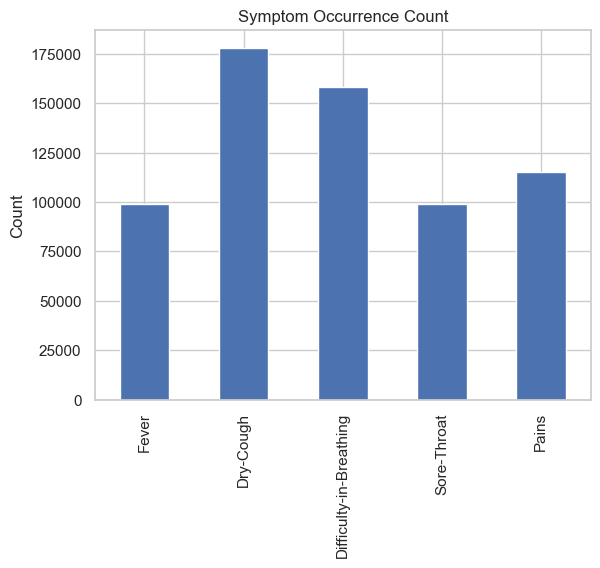

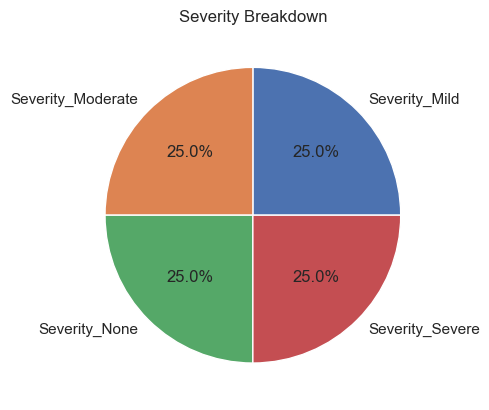


=== EDA for dataset_2 ===
Shape: (18110, 9)

🔹 Missing Values (%):
Series([], dtype: float64)

🔹 Value Counts (Top Categorical Columns):

▶ Time:
Time
8:00 AM     16472
5:00 PM       899
6:00 PM       600
7:30 PM        56
9:30 PM        28
8:30 PM        28
10:00 AM       27
Name: count, dtype: int64

▶ ConfirmedForeignNational:
ConfirmedForeignNational
-     17664
0       314
1        39
2        36
14       25
3        12
10        6
8         5
7         3
6         3
11        2
9         1
Name: count, dtype: int64

🔹 Descriptive Stats (Numeric Columns):
                Sno         Cured         Deaths     Confirmed
count  18110.000000  1.811000e+04   18110.000000  1.811000e+04
mean    9055.500000  2.786375e+05    4052.402264  3.010314e+05
std     5228.051023  6.148909e+05   10919.076411  6.561489e+05
min        1.000000  0.000000e+00       0.000000  0.000000e+00
25%     4528.250000  3.360250e+03      32.000000  4.376750e+03
50%     9055.500000  3.336400e+04     588.000000  3.97

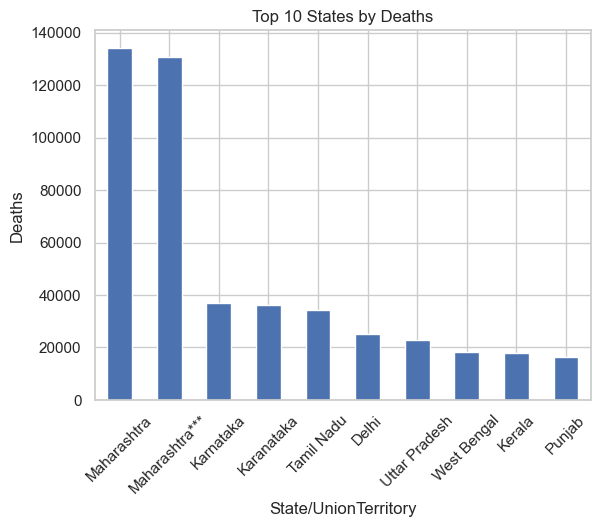

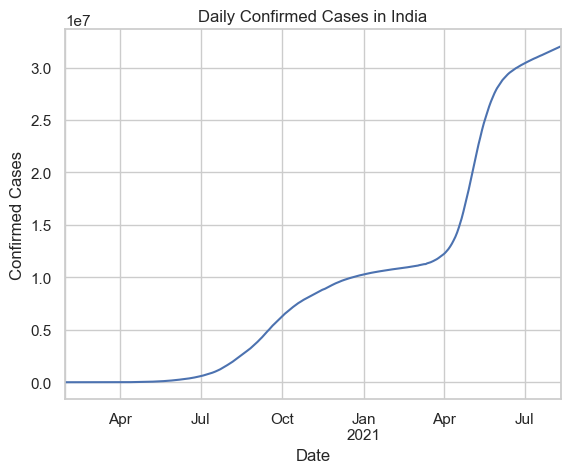


=== EDA for dataset_3 ===
Shape: (49068, 10)

🔹 Missing Values (%):
Province/State    70.114943
dtype: float64

🔹 Value Counts (Top Categorical Columns):

▶ WHO Region:
WHO Region
Europe                   15040
Western Pacific          10340
Africa                    9024
Americas                  8648
Eastern Mediterranean     4136
South-East Asia           1880
Name: count, dtype: int64

🔹 Descriptive Stats (Numeric Columns):
                Lat          Long     Confirmed         Deaths     Recovered  \
count  49068.000000  49068.000000  4.906800e+04   49068.000000  4.906800e+04   
mean      21.433730     23.528236  1.688490e+04     884.179160  7.915713e+03   
std       24.950320     70.442740  1.273002e+05    6313.584411  5.480092e+04   
min      -51.796300   -135.000000  0.000000e+00       0.000000  0.000000e+00   
25%        7.873054    -15.310100  4.000000e+00       0.000000  0.000000e+00   
50%       23.634500     21.745300  1.680000e+02       2.000000  2.900000e+01   
75%    

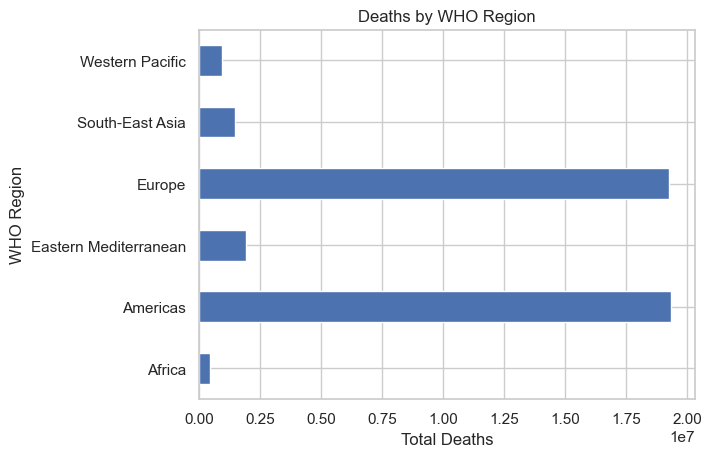

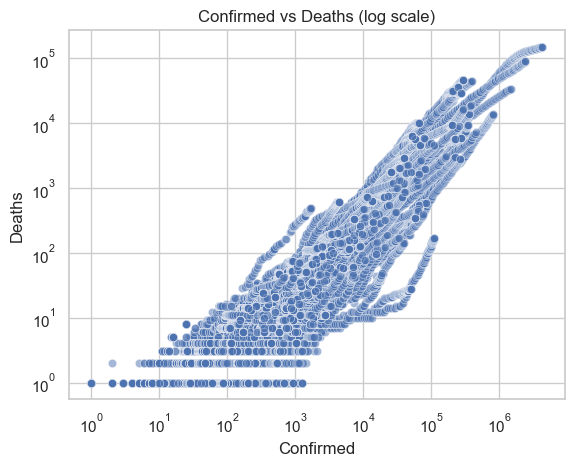


=== EDA for dataset_4 ===
Shape: (86512, 15)

🔹 Missing Values (%):
daily_vaccinations_raw                 59.124746
people_fully_vaccinated                55.148419
people_fully_vaccinated_per_hundred    55.148419
people_vaccinated                      52.267893
people_vaccinated_per_hundred          52.267893
total_vaccinations                     49.594276
total_vaccinations_per_hundred         49.594276
daily_vaccinations                      0.345617
daily_vaccinations_per_million          0.345617
dtype: float64

🔹 Value Counts (Top Categorical Columns):

🔹 Descriptive Stats (Numeric Columns):
       total_vaccinations  people_vaccinated  people_fully_vaccinated  \
count        4.360700e+04       4.129400e+04             3.880200e+04   
mean         4.592964e+07       1.770508e+07             1.413830e+07   
std          2.246004e+08       7.078731e+07             5.713920e+07   
min          0.000000e+00       0.000000e+00             1.000000e+00   
25%          5.264100e+05  

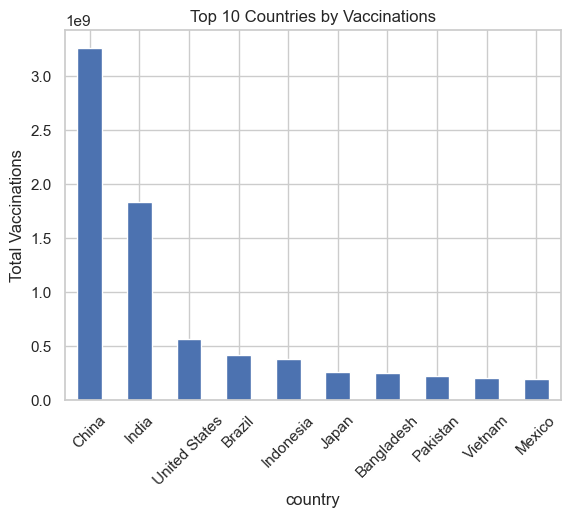

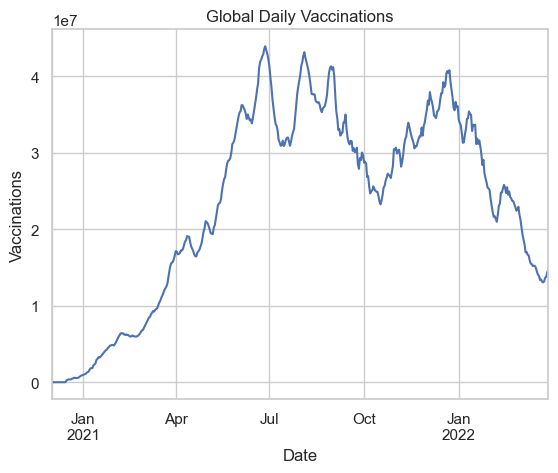


=== EDA for dataset_5 ===
Shape: (1048575, 21)

🔹 Missing Values (%):
Series([], dtype: float64)

🔹 Value Counts (Top Categorical Columns):

🔹 Descriptive Stats (Numeric Columns):
              USMER  MEDICAL_UNIT           SEX  PATIENT_TYPE       INTUBED  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean   1.632194e+00  8.980565e+00  1.499259e+00  1.190765e+00  7.952288e+01   
std    4.822084e-01  3.723278e+00  4.999997e-01  3.929041e-01  3.686889e+01   
min    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
25%    1.000000e+00  4.000000e+00  1.000000e+00  1.000000e+00  9.700000e+01   
50%    2.000000e+00  1.200000e+01  1.000000e+00  1.000000e+00  9.700000e+01   
75%    2.000000e+00  1.200000e+01  2.000000e+00  1.000000e+00  9.700000e+01   
max    2.000000e+00  1.300000e+01  2.000000e+00  2.000000e+00  9.900000e+01   

          PNEUMONIA           AGE      PREGNANT      DIABETES          COPD  \
count  1.048575e+06  1.04857

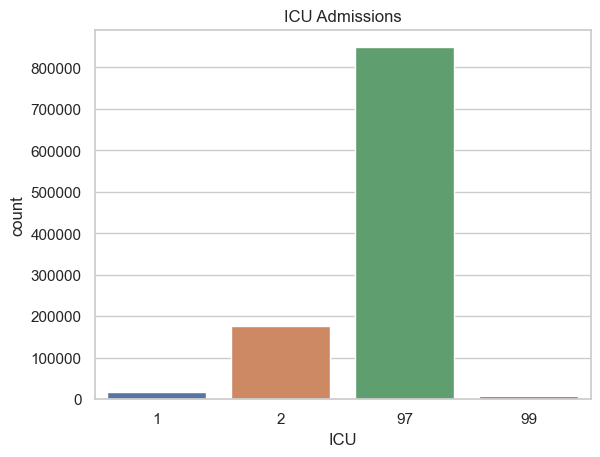

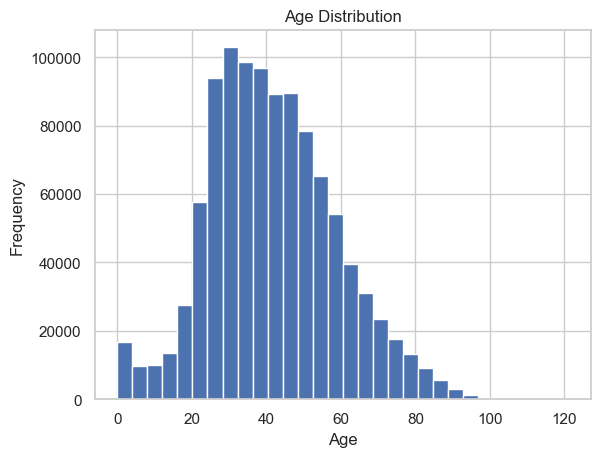

In [3]:
# Cell 3: Run EDA on All Datasets
for name, df in datasets.items():
    explore_dataset(df, name)
